# Annotation quality and outcome weights: how good must utterance labeling be before attribute weights are decision-grade

日本語要約: Persuasion for Good コーパス（寄付説得対話 1,017 件、うち 300 件に
発話単位の説得戦略アノテーション）で、「発話アノテーションを古典 NLP や AI で
自動化しても、会話属性と成果（実際の寄付）への重みは推定できるか」を検証する。
正解ラベルを理想的なアノテーターの上限とみなし、ラベルをシード付きでランダムに
破損させる連続体（ε = 0〜40%）で中間品質を模擬、TF-IDF + ロジスティック回帰の
古典 NLP アノテーターを同じ曲線上に置く。結果: 属性重みの順位相関はラベル精度
90% で約 0.9、精度 71% の古典 NLP でも約 0.8 を保ち、重み推定は個別ラベルより
アノテーション誤差にかなり頑健である。ただし個々の属性の効果は小さく、95% CI が
0 をまたぐものが多い。相関と因果の区別（説得者は相手に応じて戦略を変える）も
本文で明示する。

**What this notebook shows**

- A concrete answer to a systematization question: if per-utterance
  annotation is automated, either with classical NLP or with an
  AI annotator, can conversation-level attributes and their weights on a
  real outcome (an actual donation) still be estimated?
- Seven conversation attributes built from the Persuasion for Good
  strategy taxonomy, five annotation-dependent and two annotation-free,
  with the mapping documented as a table.
- An honest simulation design: gold human labels stand in for the upper
  bound an ideal AI annotator could reach, and seeded random corruption of
  those labels at rates from 0 to 40 percent maps the entire
  accuracy-to-distortion curve. No LLM is called anywhere; any annotator,
  human or LLM, can be placed on the measured curve by its label accuracy.
- A real classical-NLP annotator (TF-IDF plus logistic regression, trained
  on the gold subset with dialogue-level cross-validation) evaluated
  per class against gold and placed on the same curve.
- Standardized logistic weights of the attributes on donated-or-not, with
  persuadee personality controls and seeded bootstrap CIs, plus a
  secondary amount model among donors.
- The headline figure: annotation accuracy on the x axis, downstream
  weight fidelity (Spearman rank correlation against gold weights) on the
  y axis.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score, f1_score
from sklearn.model_selection import GroupKFold

from voc_arc import p4g
from voc_arc.attributes import (
    ATTRIBUTES,
    build_attributes,
    degrade_labels,
    persuadee_engagement,
    strategy_attributes,
    valence_arc_end,
)
from voc_arc.classifier import MajorityBaseline, build_model, evaluate
from voc_arc.data import load_dataset, repo_root
from voc_arc.plotting import PALETTE, plot_weight_forest, set_style
from voc_arc.weights import (
    bootstrap_linear_weights,
    bootstrap_logistic_weights,
    logistic_weights,
    weight_fidelity,
)

set_style()
SEED = 42
CI = bool(os.environ.get("CI"))
N_BOOT = 200 if CI else 1000
N_REP = 10 if CI else 30
EPSILONS = (0.0, 0.1, 0.2, 0.3, 0.4)
ATTR_LIST = list(ATTRIBUTES)
CONTROL_LIST = list(p4g.CONTROL_COLUMNS)

## 1. Data: 300 gold-annotated persuasion dialogues with a real outcome

Persuasion for Good (Wang et al., ACL 2019): pairs of crowd workers
talked for at least 10 turns; one side was instructed to persuade the
other to donate part of their task payment to the charity Save the
Children. The outcome is the persuadee's actual donation deducted from
their payment after the task, not a stated intention. Donations were
capped at $2 by the payment scheme, so the handful of larger values in
the info table (up to $700) are data-entry noise and are winsorized at
the cap, as the dataset's own documentation advises.

A 300-dialogue subset carries per-sentence human labels from a taxonomy
of about 30 dialogue acts, including 10 persuasion strategies. That
subset is the gold standard for everything below; the committed
`data/sample/` copy contains all 300 dialogues, so the sample path (used
by CI) differs from the raw path only in skipping the full-corpus
projection of section 8.

In [2]:
annotated, source = p4g.load_annotated()
info, info_source = p4g.load_info()
info = info[info["dialogue_id"].isin(set(annotated["dialogue_id"]))]
outcome = p4g.prepare_outcome_controls(info)

n_dialogues = annotated["dialogue_id"].nunique()
persuader = annotated[annotated["role"] == "persuader"]
print(
    f"source={source}, dialogues={n_dialogues}, sentences={len(annotated)}, "
    f"labeled persuader sentences={persuader['strategy'].notna().sum()}"
)
print(
    f"donated (winsorized at ${p4g.DONATION_CAP:.0f}): {outcome['donated'].mean():.1%}, "
    f"mean amount among donors: ${outcome.loc[outcome['donated'] == 1, 'donation'].mean():.2f}"
)

source=raw, dialogues=300, sentences=10864, labeled persuader sentences=6017
donated (winsorized at $2): 49.3%, mean amount among donors: $0.55


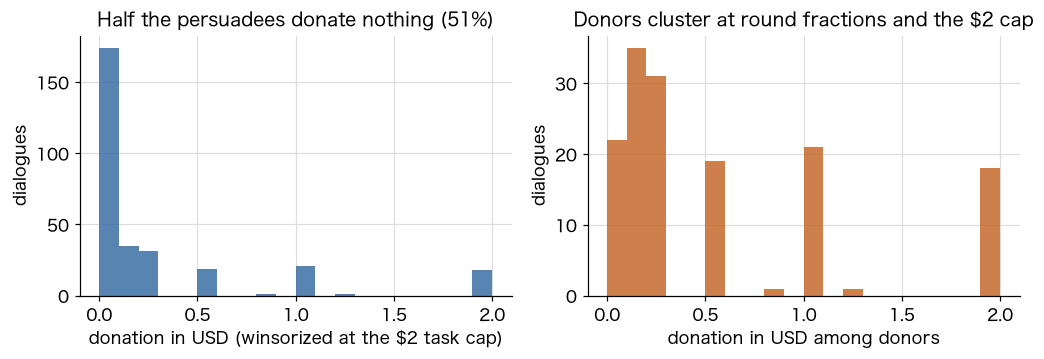

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].hist(outcome["donation"], bins=np.linspace(0, 2, 21), color=PALETTE[0], alpha=0.85)
axes[0].set_xlabel("donation in USD (winsorized at the $2 task cap)")
axes[0].set_ylabel("dialogues")
axes[0].set_title(f"Half the persuadees donate nothing ({1 - outcome['donated'].mean():.0%})")
donors = outcome.loc[outcome["donated"] == 1, "donation"]
axes[1].hist(donors, bins=np.linspace(0, 2, 21), color=PALETTE[1], alpha=0.85)
axes[1].set_xlabel("donation in USD among donors")
axes[1].set_ylabel("dialogues")
axes[1].set_title("Donors cluster at round fractions and the $2 cap")
plt.tight_layout()

### Strategy taxonomy and its mapping

The raw persuader taxonomy is finer than what the attribute layer needs,
so it is mapped onto six classes. The mapping (`voc_arc.p4g.STRATEGY_MAP`)
is a modeling choice, documented here in full:

| Raw label (`er_label_1`) | Mapped class | Rationale |
|---|---|---|
| logical-appeal | logical_appeal | reasoning about impact and efficiency |
| emotion-appeal | emotion_appeal | eliciting empathy, guilt, distress |
| credibility-appeal | credibility_appeal | organization reputation, evidence |
| personal-story | personal_story | self-disclosure strategies bundled: |
| self-modeling | personal_story | narratives and own-donation modeling |
| proposition-of-donation | donation_ask | the three explicit ask moves |
| ask-donation-amount | donation_ask | bundled into one "ask" class |
| ask-donate-more | donation_ask | |
| everything else (about 20 acts) | other | greetings, thanks, inquiries, donation logistics, acknowledgements |

The class counts below show why `other` exists: over half of persuader
sentences are conversational scaffolding, not persuasion strategy.

In [4]:
strategy_counts = persuader["strategy"].value_counts().reindex(list(p4g.STRATEGIES))
raw_counts = persuader["er_label"].value_counts()
summary = pd.DataFrame(
    {
        "sentences": strategy_counts,
        "share": (strategy_counts / strategy_counts.sum()).round(3),
    }
)
print(summary)
print(f"\nraw taxonomy size: {raw_counts.size} labels; largest raw label: {raw_counts.index[0]}")

                    sentences  share
strategy                            
logical_appeal            469  0.078
emotion_appeal            377  0.063
credibility_appeal       1083  0.180
personal_story            316  0.053
donation_ask              475  0.079
other                    3297  0.548

raw taxonomy size: 27 labels; largest raw label: credibility-appeal


## 2. Seven conversation attributes

One row per dialogue. Rates are per persuader sentence, so dialogue
length does not mechanically inflate them.

| # | Attribute | Definition | Needs annotation |
|---|---|---|---|
| 1 | logical_appeal_rate | share of persuader sentences using logical appeal | yes |
| 2 | emotional_appeal_rate | share using emotion appeal | yes |
| 3 | credibility_appeal_rate | share using credibility appeal | yes |
| 4 | personal_story_rate | share using self-disclosure (personal story or self-modeling) | yes |
| 5 | ask_timing | normalized position (0 = first sentence, 1 = last) of the first explicit donation ask; censored at 1 when no ask occurs (45 of 300 dialogues) | yes |
| 6 | persuadee_engagement | share of persuadee sentences containing a question mark | no (raw text) |
| 7 | valence_arc_end | final EWMA-smoothed expected valence of the persuadee, from the DailyDialog emotion classifier of notebooks 01-03 | no (transferred model) |

Attributes 6 and 7 are deliberate annotation-free contrasts: whatever the
noise continuum does to attributes 1-5, these two stay fixed, which is
exactly what a practitioner mixing annotated and surface features would
experience. Attribute 7 carries a domain-transfer caveat stated in
section 4.

Controls: the persuadee's Big-Five scores (extrovert, agreeable,
conscientious, neurotic, open), age, and a male indicator from the
participant survey. Persuasion research on this corpus (Wang et al.)
reports personality-dependent receptivity, so leaving these out would
push persuadee disposition into the conversation attributes.

## 3. The classical-NLP annotator, evaluated honestly

TF-IDF (word and character n-grams) plus multinomial logistic regression,
the same architecture as the emotion classifier of notebook 01, trained
on gold strategy labels. Cross-validation is at the dialogue level
(`GroupKFold`), so no dialogue contributes sentences to both training and
prediction; every sentence gets an out-of-fold prediction from a model
that never saw its dialogue.

In [5]:
er = persuader.reset_index(drop=True)
texts = er["text"].tolist()
gold_labels = er["strategy"].to_numpy()
groups = er["dialogue_id"].to_numpy()
class_names = sorted(set(gold_labels))
to_id = {name: i for i, name in enumerate(class_names)}
y_gold = np.array([to_id[label] for label in gold_labels])

oof = np.empty(len(er), dtype=int)
for train_idx, test_idx in GroupKFold(n_splits=5).split(texts, y_gold, groups):
    fold_model = build_model(seed=SEED)
    fold_model.fit([texts[i] for i in train_idx], y_gold[train_idx])
    oof[test_idx] = fold_model.predict([texts[i] for i in test_idx])

clf_scores = evaluate(y_gold, oof)
clf_kappa = float(cohen_kappa_score(y_gold, oof))
majority = MajorityBaseline().fit(texts, y_gold)
majority_scores = evaluate(y_gold, majority.predict(texts))
print(
    f"classical NLP (out-of-fold): accuracy {clf_scores['accuracy']:.3f}, "
    f"macro-F1 {clf_scores['macro_f1']:.3f}, kappa {clf_kappa:.3f}"
)
print(
    f"majority baseline: accuracy {majority_scores['accuracy']:.3f}, "
    f"macro-F1 {majority_scores['macro_f1']:.3f}"
)
assert clf_scores["macro_f1"] > majority_scores["macro_f1"]
assert clf_scores["accuracy"] > majority_scores["accuracy"]

classical NLP (out-of-fold): accuracy 0.712, macro-F1 0.613, kappa 0.578
majority baseline: accuracy 0.548, macro-F1 0.118


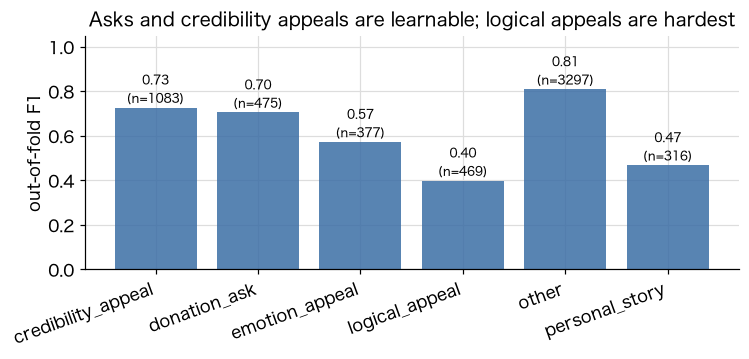

In [6]:
f1_values = f1_score(
    y_gold, oof, labels=list(range(len(class_names))), average=None, zero_division=0
)
support = pd.Series(y_gold).value_counts().reindex(range(len(class_names)), fill_value=0)
f1_frame = pd.DataFrame(
    {"f1": f1_values, "support": support.to_numpy()},
    index=pd.Index(class_names, name="strategy"),
)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(f1_frame.index, f1_frame["f1"], color=PALETTE[0], alpha=0.85)
for x, (f1_value, support) in enumerate(zip(f1_frame["f1"], f1_frame["support"], strict=True)):
    ax.text(x, f1_value, f"{f1_value:.2f}\n(n={support})", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("out-of-fold F1")
ax.set_title("Asks and credibility appeals are learnable; logical appeals are hardest")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

The per-class picture matters more than the average. Explicit donation
asks and credibility appeals have strong lexical signatures ("would you
like to donate", "Save the Children is rated") and reach F1 around 0.7.
Logical appeals are hardest (F1 around 0.4): they share vocabulary with
emotion appeals and neutral charity talk. Cohen's kappa near 0.58 says
the classifier agrees with the human annotator well above chance but far
from perfectly; the question for the rest of the notebook is what that
gap does to downstream weights.

## 4. Attributes under three annotation sources

The same attribute builder runs on three label sources: gold labels (the
upper bound an ideal AI annotator could reach), the classical-NLP
out-of-fold predictions, and gold labels randomly corrupted at rate
epsilon (each corrupted sentence gets one of the other five classes,
uniformly, under a fixed seed). Random corruption is a simplification
stated up front: real annotator errors are systematic (the confusion
concentrates in particular class pairs), so the noise curve is a clean
lower-bound-style reference map, not a claim about any specific model's
error structure. The classical-NLP point, whose errors are systematic,
shows where one real annotator lands relative to that map.

`valence_arc_end` uses the emotion classifier of notebooks 01-03, trained
on DailyDialog and applied here to persuadee sentences. That is a domain
transfer: DailyDialog is scripted small talk, Persuasion for Good is
task-oriented crowd-worker chat, and no emotion labels exist here to
verify the transfer. The attribute is kept because an end-of-conversation
valence signal is exactly what the previous notebooks argue survives
classifier noise at the aggregate level, but its coefficient should be
read with that caveat attached.

In [7]:
dd, dd_source = load_dataset()
emotion_model = build_model(seed=SEED).fit(dd["text"].tolist(), dd["emotion"].to_numpy())
print(
    f"emotion model trained on DailyDialog ({dd_source}), {dd['dialogue_id'].nunique()} dialogues"
)

emotion model trained on DailyDialog (raw), 13117 dialogues


In [8]:
attrs_gold = build_attributes(annotated, emotion_model)
nlp_label = pd.Series(None, index=annotated.index, dtype=object)
nlp_label.loc[persuader.index] = [class_names[i] for i in oof]
attrs_nlp = strategy_attributes(annotated.assign(nlp_label=nlp_label), label_col="nlp_label")
attrs_nlp["persuadee_engagement"] = attrs_gold["persuadee_engagement"]
attrs_nlp["valence_arc_end"] = attrs_gold["valence_arc_end"]
attrs_nlp = attrs_nlp[ATTR_LIST]

common = attrs_gold.index.intersection(outcome.index)
attrs_gold = attrs_gold.loc[common]
attrs_nlp = attrs_nlp.loc[common]
controls = outcome.loc[common, CONTROL_LIST]
y_donated = outcome.loc[common, "donated"]

print(attrs_gold.describe().round(3).T[["mean", "std", "min", "max"]])

                          mean    std    min    max
logical_appeal_rate      0.072  0.092  0.000  0.478
emotional_appeal_rate    0.060  0.077  0.000  0.381
credibility_appeal_rate  0.185  0.142  0.000  0.789
personal_story_rate      0.051  0.080  0.000  0.500
ask_timing               0.514  0.343  0.000  1.000
persuadee_engagement     0.223  0.163  0.000  0.900
valence_arc_end          0.270  0.235 -0.479  0.802


### Numeric validation (a): the attribute matrix aligns with the dialogues

In [9]:
assert len(attrs_gold) == n_dialogues, (len(attrs_gold), n_dialogues)
assert list(attrs_gold.columns) == ATTR_LIST
assert not attrs_gold.isna().any().any()
assert attrs_gold.index.equals(attrs_nlp.index) and attrs_gold.index.equals(y_donated.index)
print(
    f"attribute matrix: {attrs_gold.shape[0]} dialogues x {attrs_gold.shape[1]} attributes, no missing values"
)

attribute matrix: 300 dialogues x 7 attributes, no missing values


## 5. Weights under gold annotation

Logistic regression of donated-or-not on the z-scored attributes plus the
persuadee controls; coefficients are log-odds per standard deviation.
Uncertainty: percentile bootstrap over dialogues, seeded. This is a
descriptive model of associations. It is not causal: persuaders adapt
their strategy to the persuadee they face, so a negative weight on an
appeal can mean "this appeal backfires" or "this appeal gets deployed on
reluctant donors", and this design cannot separate the two.

In [10]:
X_gold = attrs_gold.join(controls)
weights_gold = bootstrap_logistic_weights(X_gold, y_donated, n_boot=N_BOOT, seed=SEED)
print(weights_gold.round(3))

                          coef     lo     hi  excludes_zero
logical_appeal_rate     -0.021 -0.280  0.262          False
emotional_appeal_rate    0.090 -0.158  0.366          False
credibility_appeal_rate -0.250 -0.586  0.050          False
personal_story_rate      0.067 -0.231  0.371          False
ask_timing               0.082 -0.169  0.356          False
persuadee_engagement    -0.265 -0.588 -0.003           True
valence_arc_end          0.243 -0.020  0.539          False
extrovert                0.045 -0.267  0.369          False
agreeable                0.271 -0.078  0.722          False
conscientious            0.119 -0.201  0.478          False
neurotic                 0.171 -0.101  0.497          False
open                     0.239 -0.106  0.648          False
age                      0.300  0.051  0.638           True
is_male                  0.012 -0.263  0.322          False


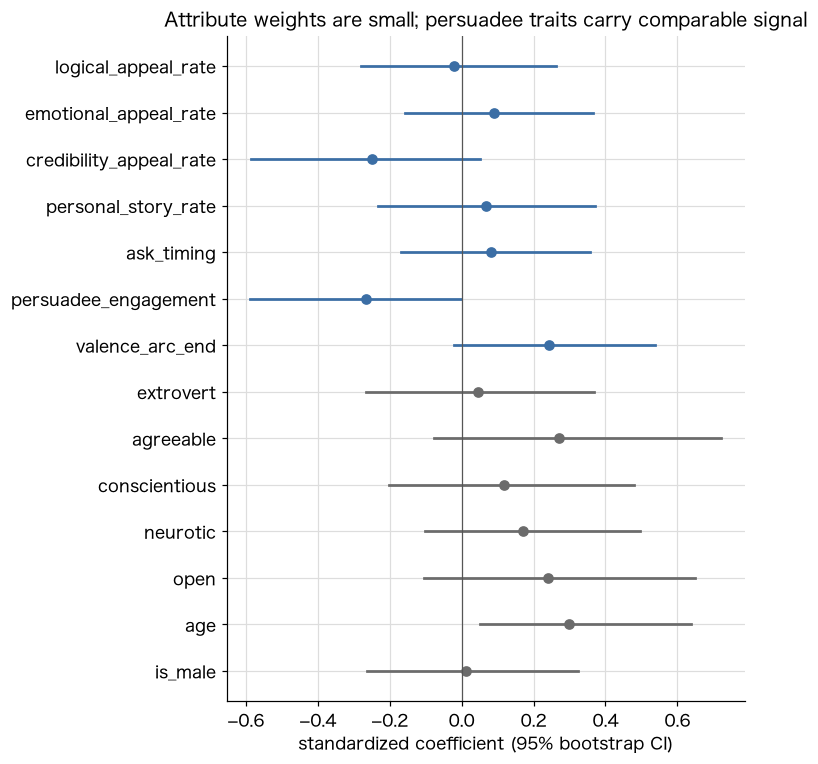

In [11]:
plot_weight_forest(
    weights_gold,
    title="Attribute weights are small; persuadee traits carry comparable signal",
    highlight=ATTR_LIST,
)
plt.tight_layout()

### Numeric validation (b): CIs are computed, finite, and read honestly

In [12]:
assert np.isfinite(weights_gold[["coef", "lo", "hi"]].to_numpy()).all()
assert (weights_gold["lo"] <= weights_gold["coef"]).all()
assert (weights_gold["coef"] <= weights_gold["hi"]).all()
significant = weights_gold.loc[ATTR_LIST].query("excludes_zero").index.tolist()
if significant:
    print(f"attribute CIs excluding zero at the 95% level: {significant}")
else:
    print(
        "honest result: no attribute CI excludes zero at the 95% level; "
        "with 300 dialogues, individual attribute effects of this size are "
        "not separable from noise, and the notebook treats them as ranked "
        "tendencies, not established effects"
    )

attribute CIs excluding zero at the 95% level: ['persuadee_engagement']


### Secondary model: amount among donors

Linear regression of log1p(donation) on the same design, among donors
only. Selection into donating is not modeled, so this describes "how much,
given that they gave", conditional on the first model's outcome.

In [13]:
donor_idx = y_donated[y_donated == 1].index
weights_amount = bootstrap_linear_weights(
    X_gold.loc[donor_idx],
    np.log1p(outcome.loc[donor_idx, "donation"]),
    n_boot=N_BOOT,
    seed=SEED,
)
print(f"donors: {len(donor_idx)}")
print(weights_amount.round(3))

donors: 148
                          coef     lo     hi  excludes_zero
logical_appeal_rate     -0.030 -0.086  0.022          False
emotional_appeal_rate    0.003 -0.062  0.063          False
credibility_appeal_rate -0.002 -0.068  0.073          False
personal_story_rate     -0.036 -0.085  0.012          False
ask_timing               0.040 -0.017  0.098          False
persuadee_engagement     0.008 -0.064  0.068          False
valence_arc_end          0.028 -0.036  0.088          False
extrovert               -0.033 -0.100  0.027          False
agreeable               -0.041 -0.109  0.043          False
conscientious            0.014 -0.055  0.072          False
neurotic                 0.034 -0.026  0.091          False
open                    -0.034 -0.104  0.035          False
age                      0.027 -0.037  0.078          False
is_male                  0.031 -0.033  0.097          False


## 6. The annotation-quality continuum

For each corruption rate epsilon, the gold labels are corrupted `N_REP`
times with different seeds; each replicate rebuilds the five
annotation-dependent attributes (the two annotation-free ones stay
fixed), refits the logistic model, and the resulting attribute weight
vector is compared with the gold weight vector by Spearman rank
correlation over the seven attributes. The question this metric asks is a
decision question: does the degraded annotation still rank the attributes
in the same order of importance? The classical-NLP annotator goes through
the identical pipeline once, using its out-of-fold labels.

In [14]:
coef_gold = logistic_weights(X_gold, y_donated, seed=SEED)
attrs_free = attrs_gold[["persuadee_engagement", "valence_arc_end"]]

records = []
for epsilon in EPSILONS:
    for rep in range(N_REP):
        noise_seed = 10_000 * rep + int(round(epsilon * 100))
        degraded = degrade_labels(annotated["strategy"], epsilon, seed=noise_seed)
        realized_accuracy = float(
            (degraded[persuader.index] == annotated.loc[persuader.index, "strategy"]).mean()
        )
        attrs_deg = strategy_attributes(
            annotated.assign(degraded_label=degraded), label_col="degraded_label"
        )
        X_deg = attrs_deg.join(attrs_free).join(controls).loc[common, X_gold.columns]
        coef_deg = logistic_weights(X_deg, y_donated, seed=SEED)
        records.append(
            {
                "epsilon": epsilon,
                "rep": rep,
                "accuracy": realized_accuracy,
                "fidelity": weight_fidelity(coef_deg, coef_gold, ATTR_LIST),
            }
        )
curve = pd.DataFrame(records)
curve_summary = curve.groupby("epsilon").agg(
    accuracy=("accuracy", "mean"),
    fidelity_mean=("fidelity", "mean"),
    fidelity_sd=("fidelity", "std"),
)
print(curve_summary.round(3))

         accuracy  fidelity_mean  fidelity_sd
epsilon                                      
0.0         1.000          1.000        0.000
0.1         0.900          0.870        0.101
0.2         0.800          0.838        0.108
0.3         0.700          0.796        0.119
0.4         0.598          0.790        0.121


In [15]:
coef_nlp = logistic_weights(attrs_nlp.join(controls), y_donated, seed=SEED)
nlp_accuracy = clf_scores["accuracy"]
nlp_fidelity = weight_fidelity(coef_nlp, coef_gold, ATTR_LIST)
print(
    f"classical NLP annotator: label accuracy {nlp_accuracy:.3f}, "
    f"weight fidelity {nlp_fidelity:.3f}"
)

classical NLP annotator: label accuracy 0.712, weight fidelity 0.821


### Numeric validation (c): fidelity is exactly 1 at zero noise and degrades with it

In [16]:
fid_zero = curve.loc[curve["epsilon"] == 0.0, "fidelity"]
assert (fid_zero == 1.0).all(), "zero corruption must reproduce the gold weights exactly"
mean_by_eps = curve_summary["fidelity_mean"]
assert mean_by_eps.loc[0.4] < mean_by_eps.loc[0.1], (
    f"expected fidelity at eps=0.4 ({mean_by_eps.loc[0.4]:.3f}) below "
    f"eps=0.1 ({mean_by_eps.loc[0.1]:.3f})"
)
print(
    f"fidelity: {mean_by_eps.loc[0.0]:.3f} (eps=0) -> {mean_by_eps.loc[0.1]:.3f} (eps=0.1) "
    f"-> {mean_by_eps.loc[0.4]:.3f} (eps=0.4)"
)

fidelity: 1.000 (eps=0) -> 0.870 (eps=0.1) -> 0.790 (eps=0.4)


## 7. Headline figure: annotation accuracy vs downstream weight fidelity

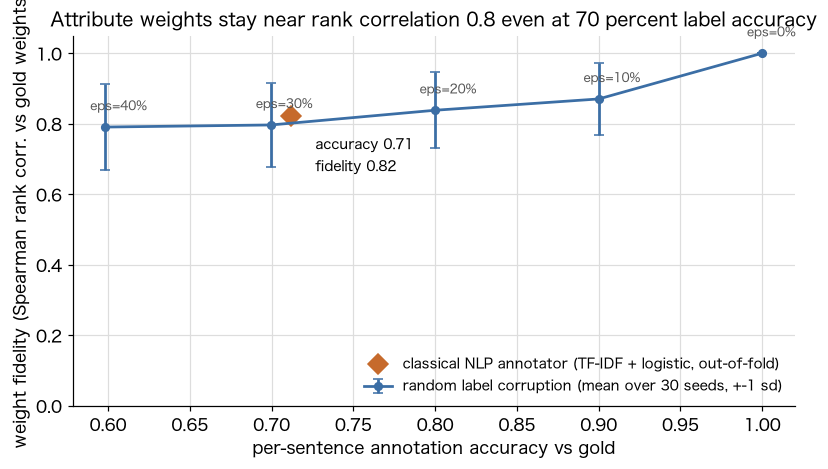

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.errorbar(
    curve_summary["accuracy"],
    curve_summary["fidelity_mean"],
    yerr=curve_summary["fidelity_sd"],
    fmt="-o",
    color=PALETTE[0],
    lw=1.8,
    ms=5,
    capsize=3,
    label=f"random label corruption (mean over {N_REP} seeds, +-1 sd)",
)
ax.plot(
    nlp_accuracy,
    nlp_fidelity,
    "D",
    color=PALETTE[1],
    ms=9,
    label="classical NLP annotator (TF-IDF + logistic, out-of-fold)",
)
ax.annotate(
    f"accuracy {nlp_accuracy:.2f}\nfidelity {nlp_fidelity:.2f}",
    (nlp_accuracy, nlp_fidelity),
    textcoords="offset points",
    xytext=(16, -36),
    fontsize=9,
)
for epsilon, row in curve_summary.iterrows():
    ax.annotate(
        f"eps={epsilon:.0%}",
        (row["accuracy"], row["fidelity_mean"]),
        textcoords="offset points",
        xytext=(-10, 11),
        fontsize=8,
        color="#555555",
    )
ax.set_xlabel("per-sentence annotation accuracy vs gold")
ax.set_ylabel("weight fidelity (Spearman rank corr. vs gold weights)")
ax.set_ylim(0, 1.05)
ax.set_title("Attribute weights stay near rank correlation 0.8 even at 70 percent label accuracy")
ax.legend(frameon=False, loc="lower right", fontsize=9)
plt.tight_layout()
if source == "raw":
    fig.savefig(repo_root() / "assets" / "annotation_quality_vs_weights.png", dpi=150)

Two readings of this figure. First, the encouraging one: dialogue-level
attribute weights are far more robust to annotation error than the
per-sentence labels themselves, because rates average over roughly 20
persuader sentences per dialogue and random errors partially cancel; even
40 percent corruption keeps the attribute ranking around 0.8. Second, the
cautionary one: the two annotation-free attributes anchor the ranking at
every noise level, and the curve flattens rather than collapsing, so a
high fidelity number alone does not certify the annotation. The classical
NLP annotator sits close to the random-corruption curve at its accuracy
level; its systematic confusions (logical vs emotion appeals) do not
distort the weight ranking much more than random noise of the same
magnitude on this corpus.

## 8. Projection to the full corpus (runs when the raw data is available)

The payoff of an automated annotator is scale: 300 dialogues carry gold
labels, but the corpus has 1,017 with recorded outcomes. Here the
classifier labels every persuader sentence in the full corpus (using
out-of-fold predictions for the 300 annotated dialogues and a model
trained on all 300 for the rest), and the weight model is refit with 3.4
times the sample.

full-corpus dialogues with outcome: 1017
                         coef_gold_n300  coef_nlp_n1017  ci_width_n300  \
logical_appeal_rate              -0.021          -0.071          0.542   
emotional_appeal_rate             0.090          -0.095          0.524   
credibility_appeal_rate          -0.250          -0.042          0.636   
personal_story_rate               0.067          -0.010          0.602   
ask_timing                        0.082          -0.019          0.525   
persuadee_engagement             -0.265          -0.004          0.585   
valence_arc_end                   0.243           0.411          0.559   

                         ci_width_full  
logical_appeal_rate              0.271  
emotional_appeal_rate            0.271  
credibility_appeal_rate          0.309  
personal_story_rate              0.292  
ask_timing                       0.266  
persuadee_engagement             0.299  
valence_arc_end                  0.262  

median CI width shrinks from 0.559 to

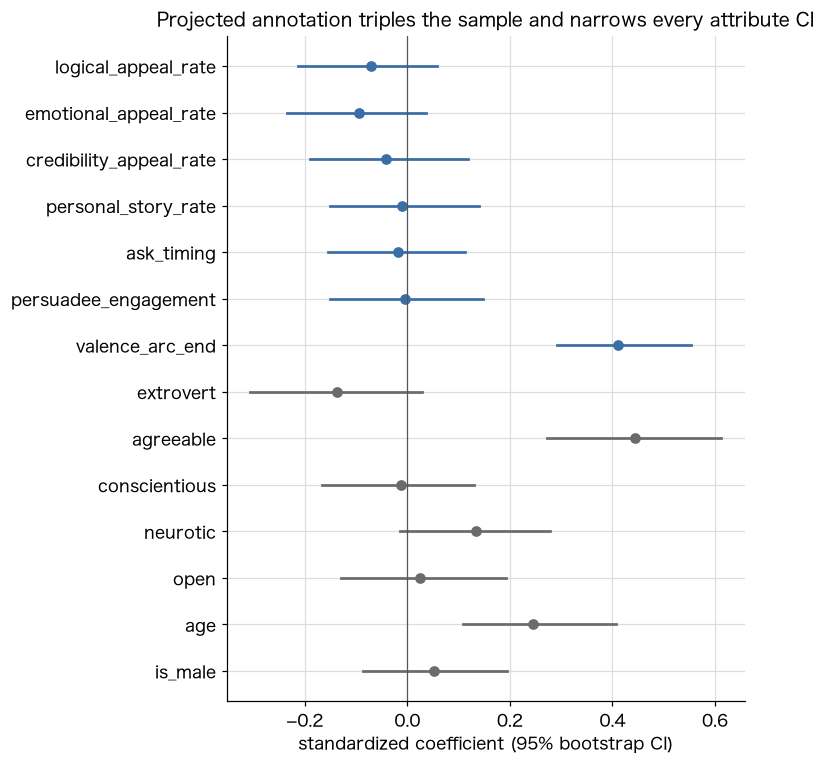

In [18]:
if p4g.full_dialog_path().is_file() and info_source == "raw":
    full = p4g.load_full_dialog()
    rest = full[~full["dialogue_id"].isin(set(annotated["dialogue_id"]))].copy()
    final_model = build_model(seed=SEED).fit(texts, y_gold)
    rest_persuader = rest["role"] == "persuader"
    rest["nlp_label"] = pd.Series(None, index=rest.index, dtype=object)
    rest.loc[rest_persuader, "nlp_label"] = [
        class_names[i] for i in final_model.predict(rest.loc[rest_persuader, "text"].tolist())
    ]
    attrs_rest = strategy_attributes(rest, label_col="nlp_label")
    attrs_rest["persuadee_engagement"] = persuadee_engagement(rest).reindex(attrs_rest.index)
    attrs_rest["valence_arc_end"] = valence_arc_end(rest, emotion_model).reindex(attrs_rest.index)
    attrs_full = pd.concat([attrs_nlp, attrs_rest[ATTR_LIST]])

    outcome_full = p4g.prepare_outcome_controls(p4g.load_info_raw())
    idx_full = attrs_full.index.intersection(outcome_full.index)
    X_full = attrs_full.loc[idx_full].join(outcome_full.loc[idx_full, CONTROL_LIST])
    y_full = outcome_full.loc[idx_full, "donated"]
    weights_full = bootstrap_logistic_weights(X_full, y_full, n_boot=N_BOOT, seed=SEED)

    width_300 = (weights_gold["hi"] - weights_gold["lo"]).loc[ATTR_LIST]
    width_full = (weights_full["hi"] - weights_full["lo"]).loc[ATTR_LIST]
    comparison = pd.DataFrame(
        {
            "coef_gold_n300": weights_gold.loc[ATTR_LIST, "coef"],
            f"coef_nlp_n{len(y_full)}": weights_full.loc[ATTR_LIST, "coef"],
            "ci_width_n300": width_300,
            "ci_width_full": width_full,
        }
    ).round(3)
    print(f"full-corpus dialogues with outcome: {len(y_full)}")
    print(comparison)
    print(
        f"\nmedian CI width shrinks from {width_300.median():.3f} to {width_full.median():.3f}; "
        f"attributes excluding zero on the full corpus: "
        f"{weights_full.loc[ATTR_LIST].query('excludes_zero').index.tolist()}"
    )
    plot_weight_forest(
        weights_full,
        title="Projected annotation triples the sample and narrows every attribute CI",
        highlight=ATTR_LIST,
    )
    plt.tight_layout()
else:
    print(
        "raw Persuasion for Good files not found; skipping the full-corpus "
        "projection (run 'python scripts/download_data.py p4g' to enable it)"
    )

The projection buys precision, but read the comparison table carefully.
Two different things move the coefficients. The annotated attributes are
now noisy measurements of their true values, and errors-in-variables
attenuation pulls them toward zero; `credibility_appeal_rate` shrinking
from -0.25 to near zero is the textbook picture. Separately,
`persuadee_engagement` is annotation-free, so its collapse from -0.27 to
zero cannot be attenuation: the estimation sample changed, which says the
300-dialogue coefficient was fragile to begin with. Meanwhile the
annotation-free `valence_arc_end` strengthens and becomes the one
attribute whose CI excludes zero at n=1,017. The projection is defensible
for prioritization and for the annotation-free attributes; it is not a
way to sharpen coefficient-level claims about the annotated ones.

## 9. Reading the weights

The tendencies of the committed run, stated as associations with their
competing explanations:

- `valence_arc_end` (positive on both fits, CI excluding zero on the full
  corpus): conversations that end with the persuadee in a positive
  emotional state co-occur with donations. The reverse causal path is
  wide open, since agreeing to donate produces positive closing turns
  ("happy to help").
- `persuadee_engagement` (negative on the gold subset, the one attribute
  whose CI excludes zero there; near zero on the full corpus):
  question-heavy persuadees donate less in the annotated subset.
  Questions here include procedural skepticism ("how do I know this is
  legitimate"), so engagement is not the unambiguous buying signal a
  sales playbook would assume; and the disagreement between the two fits
  is a caution against reading a 300-dialogue coefficient as settled.
- `credibility_appeal_rate` (negative on gold, attenuated on the
  projection): more organization-credentials talk co-occurs with fewer
  donations. The endogenous reading is at least as plausible as the
  causal one: persuaders reach for credentials when facing resistance.
- `emotional_appeal_rate` and `personal_story_rate` (weak, CIs include
  zero): directionally consistent with the persuasion literature on
  empathy and self-disclosure on the gold fit, but not separable from
  noise at this sample size.
- Persuadee traits (`agreeable`, `open`, `age`) carry weights comparable
  to the strongest conversation attributes: who you talk to matters about
  as much as how you talk, which is itself a finding a conversation-only
  dashboard would miss.

## Limitations

- The noise model is uniform random corruption; real annotators, human or
  LLM, make systematic errors. The single classical-NLP point suggests
  systematic error of this size behaves similarly here, but that is one
  annotator on one corpus, not a general law.
- "AI annotation upper bound = gold labels" is an assumption of the
  simulation design, stated rather than measured; no LLM was run. An
  actual LLM annotator can be placed on the curve by measuring its
  per-sentence accuracy against a gold slice.
- The weights are associations. Strategy choice adapts to the persuadee,
  donation causes late-conversation features (especially the valence
  ending), and 300 gold dialogues bound the precision; several attribute
  CIs include zero, and the notebook ranks tendencies instead of claiming
  effects.
- `valence_arc_end` rests on a DailyDialog-to-P4G domain transfer with no
  in-domain emotion labels to validate it.
- `ask_timing` censors the 15 percent of dialogues without an explicit
  ask at 1.0, mixing "asked late" with "never asked".
- The outcome is a $2-capped donation by crowd workers paid to converse;
  effect sizes and base rates will differ in any commercial VoC setting,
  and what transfers is the measurement design, not the numbers.

## References

- Wang, Shi, Kim, Oh, Yang, Zhang, Yu. "Persuasion for Good: Towards a
  Personalized Persuasive Dialogue System for Social Good." ACL 2019.
  Dataset: gitlab.com/ucdavisnlp/persuasionforgood (Apache-2.0).
- Li, Su, Shen, Li, Cao, Niu. "DailyDialog: A Manually Labelled
  Multi-turn Dialogue Dataset." IJCNLP 2017 (emotion model for
  `valence_arc_end`).